## Описание проекта

**Датасет:** Brazilian E-Commerce Public Dataset by Olist (2016–2018).

**Что внутри:** 9 таблиц с данными о заказах, клиентах, товарах, продавцах, платежах, 
отзывах и геолокации.

**Задачи ноутбука:**
*   Загрузить данные и провести первичный осмотр: структура, типы, уникальные значения.
*   Провести анализ пропусков: найти, объяснить, принять решения по обработке.
*   Построить витрину — объединить 9 таблиц в единую плоскую таблицу.
*   Обогатить витрину новыми признаками: расстояние между продавцом и покупателем, 
    базовый прогноз Olist, средняя оценка продавца.
*   Сохранить витрину для следующих этапов анализа.

**Источник данных:** [Kaggle — Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

### 1. Первичный анализ данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

# Палитра
selected_palette = sns.color_palette("RdYlGn", n_colors=20)

# Относительный путь к данным
path = os.path.join('..', 'data', 'raw')

# Загружаем CSV
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
categories = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))


print("Данные загружены")

Данные загружены


In [3]:
# Словарь с таблицами для анализа
tables = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'categories': categories
   
}

# Собираем сводку по всем таблицам
summary = []
for name, tbl in tables.items():
    summary.append({
        'Таблица': name,
        'Строк': tbl.shape[0],
        'Столбцов': tbl.shape[1],
        'Пропусков': tbl.isnull().sum().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Таблица,Строк,Столбцов,Пропусков
0,customers,99441,5,0
1,orders,99441,8,4908
2,order_items,112650,7,0
3,payments,103886,5,0
4,reviews,99224,7,145903
5,products,32951,9,2448
6,sellers,3095,4,0
7,categories,71,2,0


In [4]:
# Типы данных и уникальные значения для каждой таблицы
for name, tbl in tables.items():
    info = pd.DataFrame({
        'DataType': tbl.dtypes,
        'UniqueValues': tbl.nunique()
    })
    print(f"\n{name}")
    display(info)


customers


,DataType,UniqueValues
customer_id,object,99441
customer_unique_id,object,96096
customer_zip_code_prefix,int64,14994
customer_city,object,4119
customer_state,object,27



orders


,DataType,UniqueValues
order_id,object,99441
customer_id,object,99441
order_status,object,8
order_purchase_timestamp,object,98875
order_approved_at,object,90733
order_delivered_carrier_date,object,81018
order_delivered_customer_date,object,95664
order_estimated_delivery_date,object,459



order_items


...

,DataType,UniqueValues
product_id,object,32951
product_category_name,object,73
product_name_lenght,float64,66
product_description_lenght,float64,2960
product_photos_qty,float64,19
product_weight_g,float64,2204
product_length_cm,float64,99
product_height_cm,float64,102
product_width_cm,float64,95



sellers


,DataType,UniqueValues
seller_id,object,3095
seller_zip_code_prefix,int64,2246
seller_city,object,611
seller_state,object,23



categories


,DataType,UniqueValues
product_category_name,object,71
product_category_name_english,object,71


**Первичный осмотр:**
*   9 таблиц, от 71 до 112 650 строк.
*   Основная таблица для анализа — orders (99 441 заказ).
*   Пропуски: orders (4 908), reviews (145 903).
*   Даты хранятся как object — потребуется преобразование.

In [5]:
# Статусы заказов
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
# Типы платежей
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


*   97% заказов — delivered. Отменённые и недоставленные исключаем из анализа.
*   75% оплат — кредитной картой, 19% — boleto, 5% — voucher.
*   Для витрины оставляем только delivered заказы — это чистые данные для анализа.

In [7]:
# Пропуски по всем таблицам
for name, tbl in tables.items():
    nulls = tbl.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        null_pct = (nulls / len(tbl) * 100).round(1)
        null_info = pd.DataFrame({'Пропусков': nulls, '%': null_pct})
        print(f"\n{name}")
        display(null_info)
    else:
        print(f"\n{name}: пропусков нет")


customers: пропусков нет

orders


,Пропусков,%
order_approved_at,160,0.2
order_delivered_carrier_date,1783,1.8
order_delivered_customer_date,2965,3.0



order_items: пропусков нет

payments: пропусков нет

reviews


,Пропусков,%
review_comment_title,87656,88.3
review_comment_message,58247,58.7



products


,Пропусков,%
product_category_name,610,1.9
product_name_lenght,610,1.9
product_description_lenght,610,1.9
product_photos_qty,610,1.9
product_weight_g,2,0.0
product_length_cm,2,0.0
product_height_cm,2,0.0
product_width_cm,2,0.0



sellers: пропусков нет

categories: пропусков нет


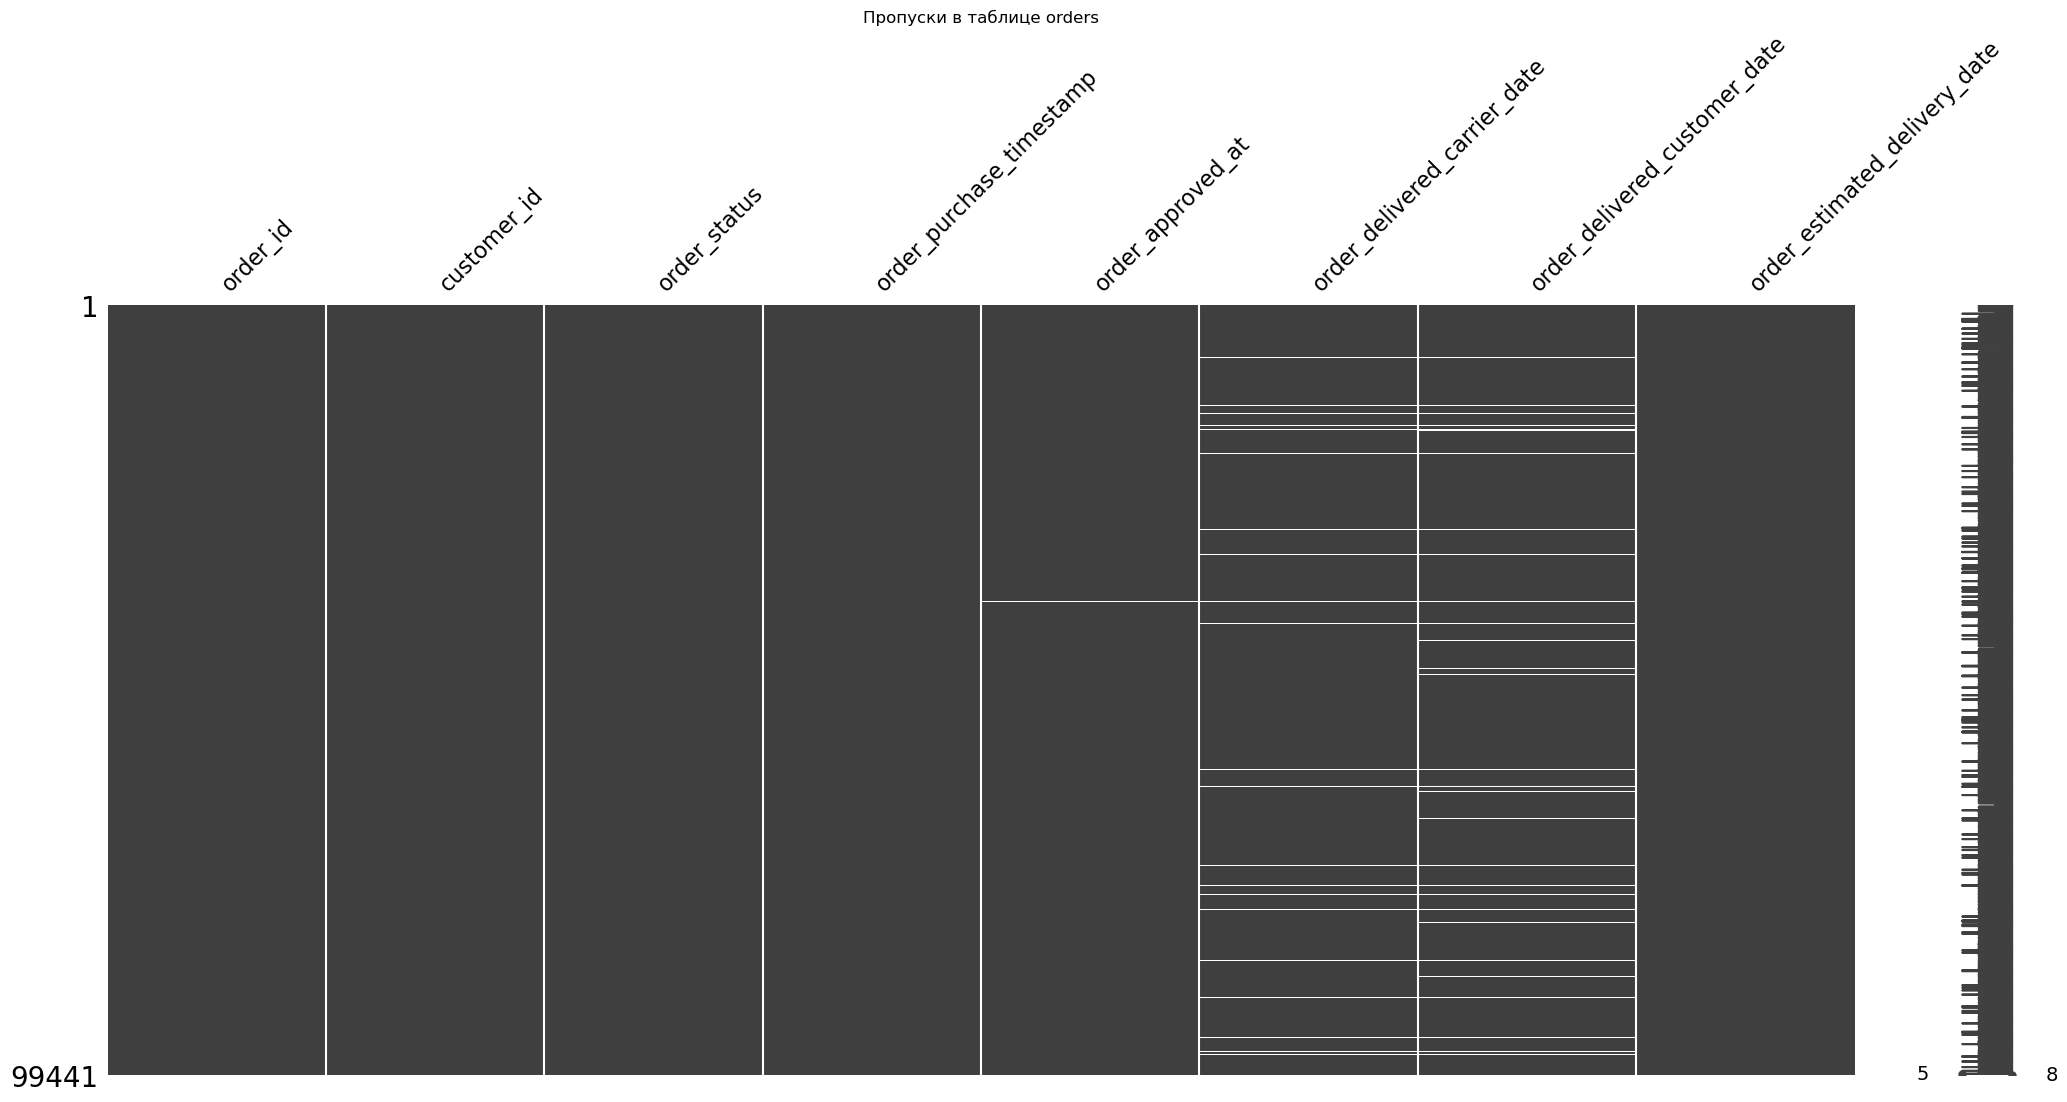

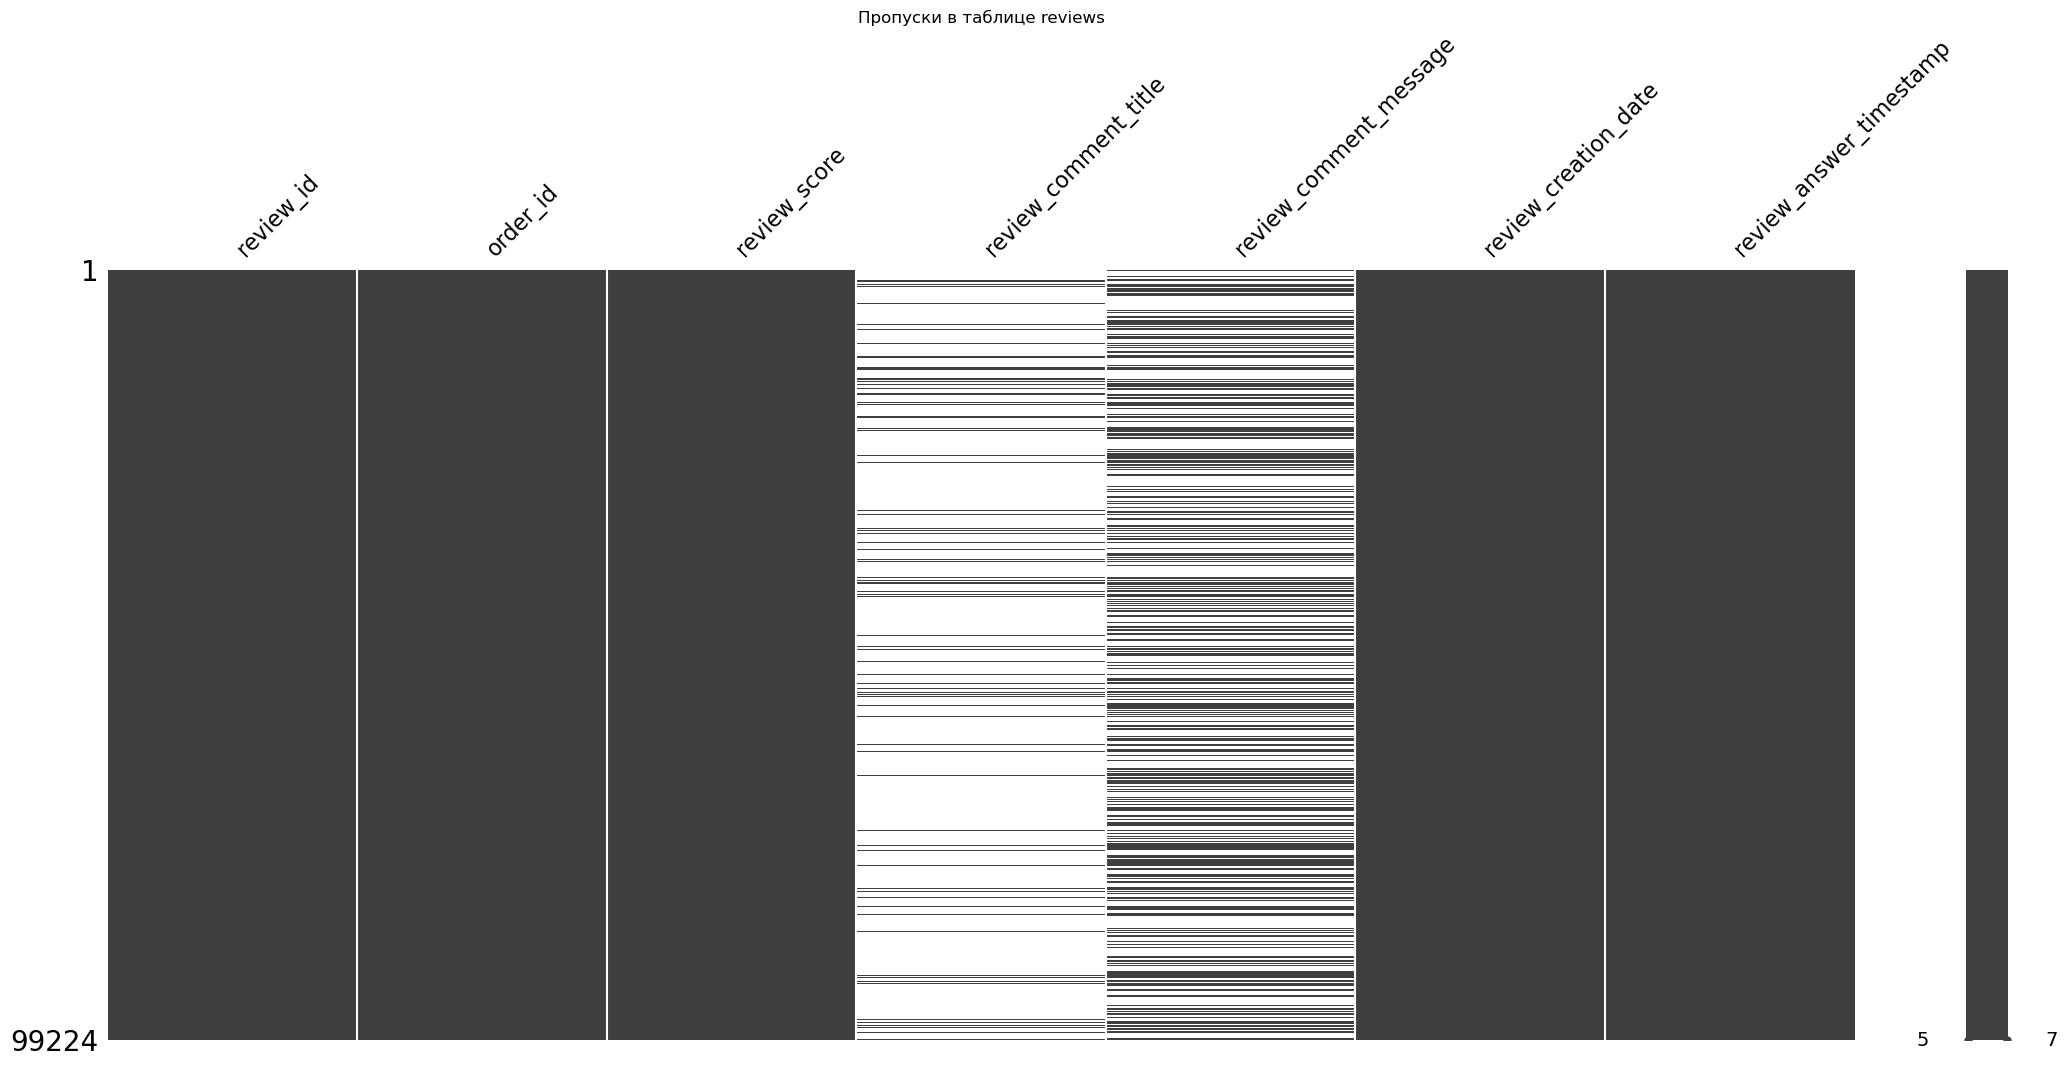

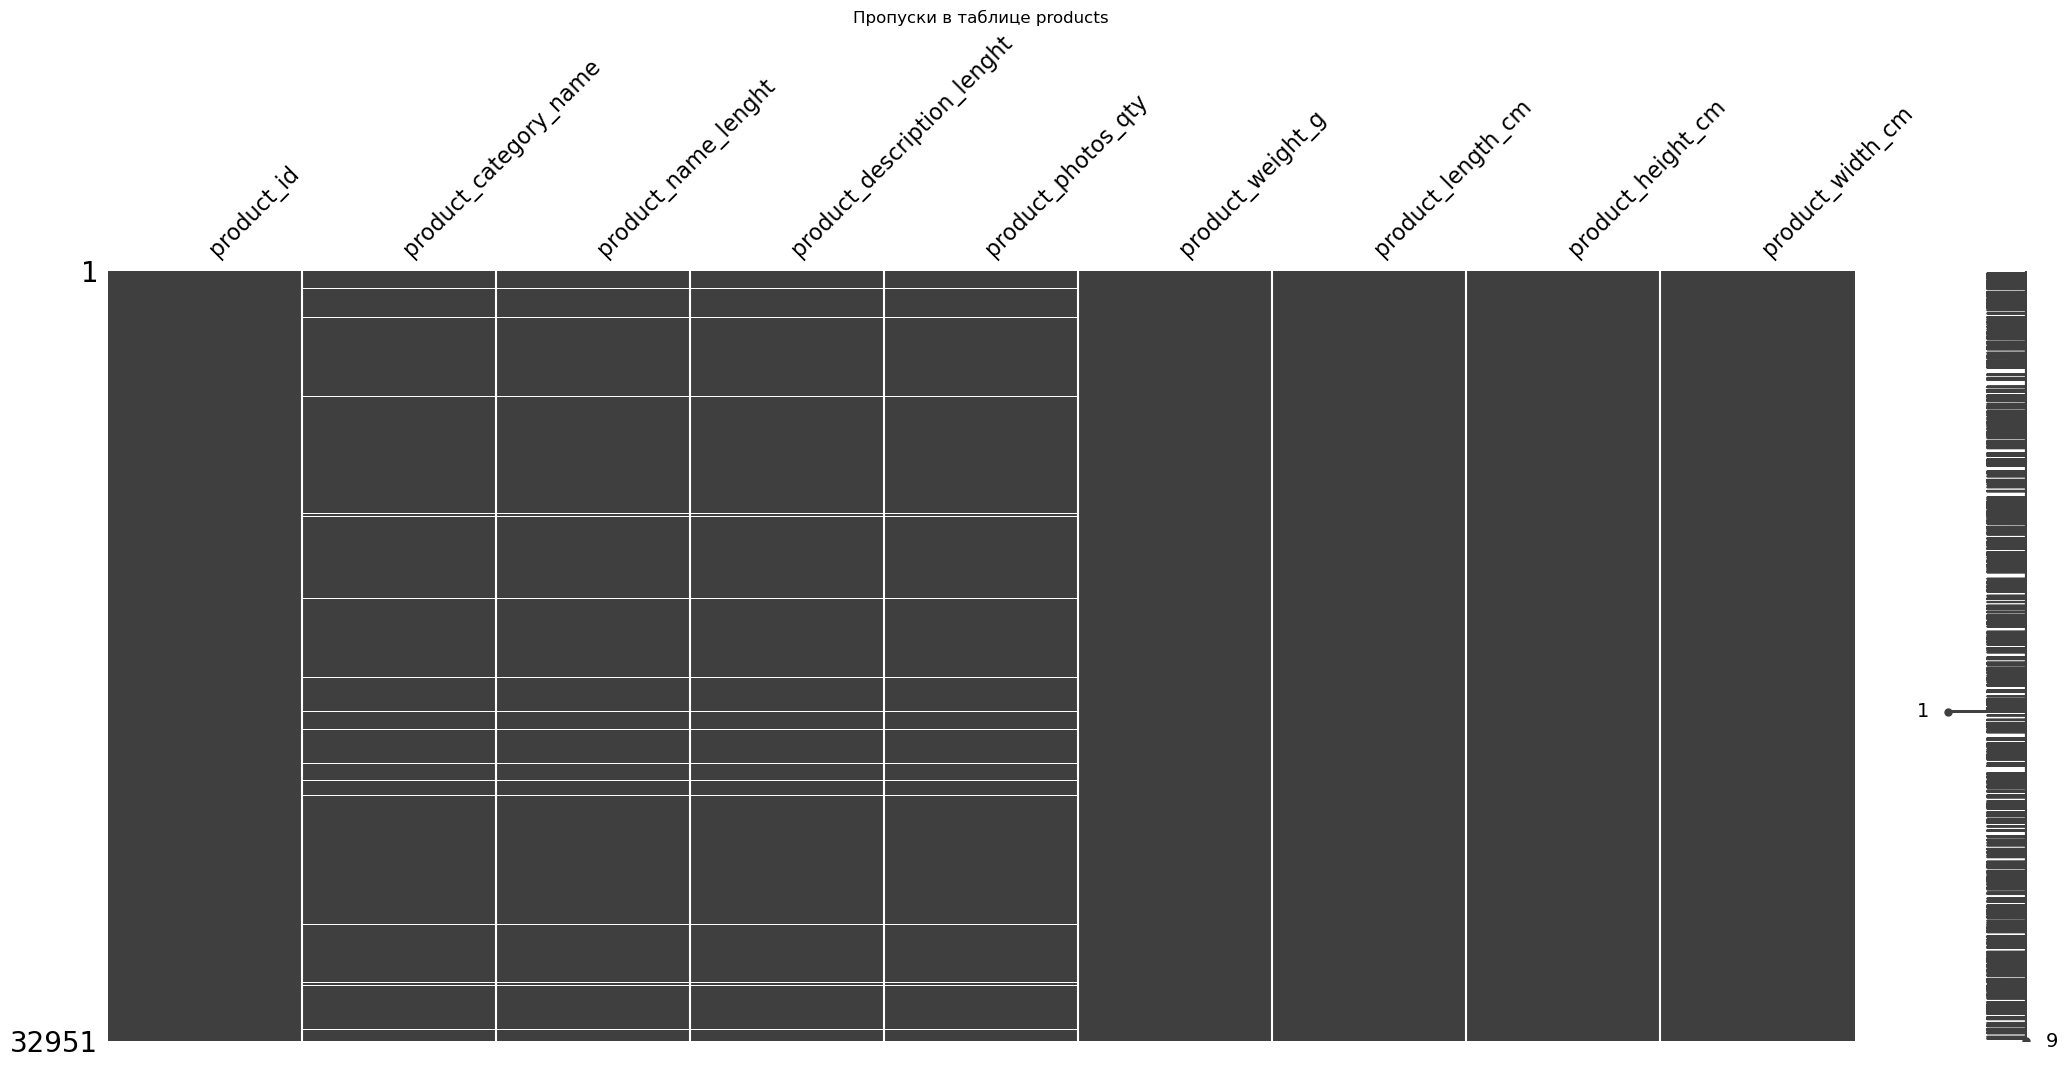

In [8]:
# Визуализация пропусков для всех таблиц, где они есть
for name, tbl in tables.items():
    null_count = tbl.isnull().sum().sum()
    if null_count > 0:
        msno.matrix(tbl)
        plt.title(f'Пропуски в таблице {name}')
        plt.show()

In [9]:
# Детально: есть ли delivered заказы без даты доставки
delivered_missing = orders[(orders['order_status'] == 'delivered') & 
                           (orders['order_delivered_customer_date'].isnull())]
print(f"delivered заказов без даты доставки: {len(delivered_missing)}")

delivered заказов без даты доставки: 8


In [10]:
# Исследование товаров с пропусками
products_missing = products[products['product_category_name'].isnull()]
print(f"Товаров без категории: {len(products_missing)}")
print(f"Из них без названия: {products_missing['product_name_lenght'].isnull().sum()}")
print(f"Из них без описания: {products_missing['product_description_lenght'].isnull().sum()}")
print(f"Из них без фото: {products_missing['product_photos_qty'].isnull().sum()}")

# Кто продаёт эти товары?
missing_ids = products_missing['product_id'].tolist()
missing_in_orders = order_items[order_items['product_id'].isin(missing_ids)]
missing_sellers = missing_in_orders['seller_id'].nunique()
print(f"\nПродавцов с такими товарами: {missing_sellers}")
print(f"Всего заказов с этими товарами: {len(missing_in_orders)}")

# Сколько из них доставлено?
missing_orders = orders[orders['order_id'].isin(missing_in_orders['order_id'])]
print(f"Статусы заказов:\n{missing_orders['order_status'].value_counts()}")

Товаров без категории: 610
Из них без названия: 610
Из них без описания: 610
Из них без фото: 610

Продавцов с такими товарами: 257
Всего заказов с этими товарами: 1603
Статусы заказов:
order_status
delivered     1392
shipped         24
canceled        14
processing      13
invoiced         8
Name: count, dtype: int64


## Анализ пропусков: 

**orders:**
*   2 965 заказов без даты доставки — 99.7% из них не в статусе delivered.
*   Решение: фильтр `order_status = 'delivered'` убирает проблему.

**reviews:**
*   Пропуски только в текстовых полях (comment_title 88%, comment_message 59%).
*   Оценки (review_score) заполнены почти полностью.
*   Решение: для анализа satisfaction используем review_score.

**products:**
*   610 товаров без категории, названия, описания и фото — одна группа товаров-черновиков.
*   Принадлежат 257 продавцам, с ними 1603 заказа, но доставленных — единицы.
*   Решение: на витрину не влияют, удалять не нужно — фильтр `delivered` их отсеет.

**Общее:** критичных пропусков нет. Витрину строим по delivered заказам.

# 2. Построение витрины данных

#### ETL: объединение таблиц в единую витрину

Собираем витрину через pandas merge — одна строка = один товар в заказе со всеми связанными полями.

Связи между таблицами показаны на схеме ниже:

![ER-диаграмма Olist](../data/processed/olist_er_diagram.png)

**Фильтр:** только доставленные заказы (order_status = 'delivered').

In [11]:
# Загружаем geolocation для перевода zip-кодов в координаты
geolocation = pd.read_csv(os.path.join(path, 'olist_geolocation_dataset.csv'))
# Оставляем уникальные пары zip_code → lat/lon (первое вхождение)
geo = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].first().reset_index()
geo.columns = ['zip_code_prefix', 'lat', 'lon']

# Добавляем координаты к продавцам
sellers_geo = sellers.merge(geo, left_on='seller_zip_code_prefix', right_on='zip_code_prefix', how='left')
sellers_geo.rename(columns={'lat': 'seller_lat', 'lon': 'seller_lon'}, inplace=True)

# Добавляем координаты к клиентам
customers_geo = customers.merge(geo, left_on='customer_zip_code_prefix', right_on='zip_code_prefix', how='left')
customers_geo.rename(columns={'lat': 'customer_lat', 'lon': 'customer_lon'}, inplace=True)

# Строим витрину с расширенными полями
df = orders.merge(customers_geo[['customer_id', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon']], 
                  on='customer_id', how='left') \
           .merge(order_items, on='order_id', how='left') \
           .merge(products[['product_id', 'product_category_name', 'product_weight_g', 
                           'product_length_cm', 'product_height_cm', 'product_width_cm']], 
                  on='product_id', how='left') \
           .merge(categories, on='product_category_name', how='left') \
           .merge(sellers_geo[['seller_id', 'seller_lat', 'seller_lon']], on='seller_id', how='left') \
           .merge(payments, on='order_id', how='left') \
           .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Оставляем нужные столбцы
columns_to_keep = [
    'order_id', 'customer_id', 'customer_city', 'customer_state',
    'customer_lat', 'customer_lon',
    'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'product_id', 'product_category_name_english',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'price', 'freight_value',
    'seller_id', 'seller_lat', 'seller_lon',
    'payment_type', 'payment_installments', 'payment_value',
    'review_score'
]

df = df[columns_to_keep].copy()
df = df[df['order_status'] == 'delivered'].copy()
df.rename(columns={'product_category_name_english': 'category'}, inplace=True)
df['category'] = df['category'].fillna('unknown')

print(f"Витрина: {df.shape}")
df.head()

Витрина: (115723, 25)


,order_id,customer_id,customer_city,customer_state,customer_lat,customer_lon,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,...,product_width_cm,price,freight_value,seller_id,seller_lat,seller_lon,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,-12.169860,-44.988369,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,...,19.0,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,-19.810119,-43.984727,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,-16.746337,-48.514624,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,...,21.0,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,-21.362358,-48.232976,credit_card,3.0,179.12,5.0


In [12]:
df.isnull().sum()

order_id                           0
customer_id                        0
customer_city                      0
customer_state                     0
customer_lat                     303
customer_lon                     303
order_status                       0
order_purchase_timestamp           0
order_delivered_customer_date      8
order_estimated_delivery_date      0
product_id                         0
category                           0
product_weight_g                  20
product_length_cm                 20
product_height_cm                 20
product_width_cm                  20
price                              0
freight_value                      0
seller_id                          0
seller_lat                       261
seller_lon                       261
payment_type                       3
payment_installments               3
payment_value                      3
review_score                     861
dtype: int64

In [13]:
# Убираем delivered-заказы без даты доставки
df = df[df['order_delivered_customer_date'].notnull()].copy()
print(f"После удаления заказов без даты доставки: {df.shape}")

После удаления заказов без даты доставки: (115715, 25)


In [14]:
df = df[df['payment_value'].notnull()].copy()
print(f"После удаления пропусков в платежах: {df.shape}")

После удаления пропусков в платежах: (115712, 25)


In [15]:
df.isnull().sum()

order_id                           0
customer_id                        0
customer_city                      0
customer_state                     0
customer_lat                     303
customer_lon                     303
order_status                       0
order_purchase_timestamp           0
order_delivered_customer_date      0
order_estimated_delivery_date      0
product_id                         0
category                           0
product_weight_g                  20
product_length_cm                 20
product_height_cm                 20
product_width_cm                  20
price                              0
freight_value                      0
seller_id                          0
seller_lat                       261
seller_lon                       261
payment_type                       0
payment_installments               0
payment_value                      0
review_score                     861
dtype: int64

In [16]:
print(f"Строк: {df.shape[0]}")
print(f"Столбцов: {df.shape[1]}")
print(f"Уникальных заказов: {df['order_id'].nunique()}")
print(f"Уникальных клиентов: {df['customer_id'].nunique()}")

Строк: 115712
Столбцов: 25
Уникальных заказов: 96469
Уникальных клиентов: 96469


In [17]:
# Feature Engineering: расстояние между продавцом и покупателем
from geopy.distance import geodesic

def calc_distance(row):
    if pd.notna(row['seller_lat']) and pd.notna(row['customer_lat']):
        return geodesic(
            (row['seller_lat'], row['seller_lon']), 
            (row['customer_lat'], row['customer_lon'])
        ).km
    return np.nan

df['distance_km'] = df.apply(calc_distance, axis=1)

# Базовый прогноз Olist: сколько дней обещали
df['estimated_delivery_days'] = (
    pd.to_datetime(df['order_estimated_delivery_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

# Средняя оценка продавца
seller_score = df.groupby('seller_id')['review_score'].mean().reset_index()
seller_score.columns = ['seller_id', 'seller_avg_score']
df = df.merge(seller_score, on='seller_id', how='left')

print("Feature engineering завершён")
print(f"distance_km: пропусков {df['distance_km'].isnull().sum()}")
print(f"estimated_delivery_days: среднее {df['estimated_delivery_days'].mean():.1f}")
print(f"seller_avg_score: среднее {df['seller_avg_score'].mean():.2f}")

Feature engineering завершён
distance_km: пропусков 563
estimated_delivery_days: среднее 23.5
seller_avg_score: среднее 4.08


**Итог:**
*   Витрина построена: 25 столбцов, ~115 000 строк.
*   Только delivered заказы.
*   Убраны 8 заказов без даты доставки и 3 записи без данных платежа.
*   Пропуски: `category` (1.4%) — товары без категории, `review_score` (0.7%) — заказы без отзыва.
*   Для анализа не критичны.
*   **Новые признаки:**
    *   `distance_km` — расстояние между продавцом и покупателем (563 пропуска — нет координат).
    *   `estimated_delivery_days` — базовый прогноз Olist (среднее 23.5 дня).
    *   `seller_avg_score` — средняя оценка продавца.
*   **Витрина доступна по ссылке:** [Google Drive](https://drive.google.com/file/d/1OOmYSXfpSI9jX_b6WAQkBg7JVVqxZGbl/view?usp=sharing)